# Import dependencies

In [90]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [91]:
# Load the dataset from Mendely
dataset = pd.read_csv("../datasets/DrugReviews.csv")

# Exploratory Data Analysis (EDA)

In [92]:
# Inspect the dataset
display(dataset.head())
print(f"Dataset shape {dataset.shape}")

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes
0,12 Hour Nasal Decongestant Spray,For Nasal Congestion,26-Jan-21,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0
1,12 Hour Nasal Decongestant Spray,For Nasal Congestion,19-Aug-22,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0
2,12 Hour Nasal Decongestant Spray,For Nasal Congestion,28-Apr-18,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0
3,5-HTP,For Anxiety,3-May-20,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345
4,5-HTP,For Anxiety,11-Jul-19,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229


Dataset shape (392510, 9)


### Columns information

- `MedicineName` - name of the medicine
- `MedicineFor` - therapeutic apllication of the medicine
- `ReviewDate`- date when the review was posted
- `UserName` - reviewer's username
- `IntakeTime` - treatment duration
- `Reviews` - review of the medicine
- `ReviewLenght` - number of character of the review
- `Rating` - rating of the medicine given by the reviewer
- `NumberOfLikes` - number of likes the review obtained

In [93]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392510 entries, 0 to 392509
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   MedicineName   392510 non-null  object
 1   MedicineFor    392510 non-null  object
 2   ReviewDate     392510 non-null  object
 3   UserName       392454 non-null  object
 4   IntakeTime     392510 non-null  object
 5   Reviews        392510 non-null  object
 6   ReviewLength   392510 non-null  int64 
 7   Rating         392510 non-null  int64 
 8   NumberOfLikes  392510 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 27.0+ MB


In [94]:
# Check for null values
dataset.isnull().sum()

MedicineName      0
MedicineFor       0
ReviewDate        0
UserName         56
IntakeTime        0
Reviews           0
ReviewLength      0
Rating            0
NumberOfLikes     0
dtype: int64

In [95]:
# Check for duplicated entries
print(f"Duplicated entries: {int(dataset.duplicated().sum())}")

Duplicated entries: 607


In [96]:
print(f"Duplicated reviews of medicines: {dataset.duplicated(['MedicineName', 'Reviews']).sum()}")

Duplicated reviews of medicines: 5473


In [97]:
print(f"Duplicated reviews of medicines: {dataset.duplicated(['MedicineName', 'Reviews', 'Rating']).sum()}")

Duplicated reviews of medicines: 5367


In [98]:
# Inspect ReviewLenght, Rating, and NumberOfLikes ranges
dataset[['ReviewLength', 'Rating', 'NumberOfLikes']].describe().T

,count,mean,std,min,25%,50%,75%,max
ReviewLength,392510.0,336.650422,262.251652,1.0,109.0,274.0,517.0,4930.0
Rating,392510.0,6.281364,3.576652,1.0,2.0,8.0,10.0,10.0
NumberOfLikes,392510.0,26.995376,49.376236,0.0,4.0,13.0,32.0,3555.0


In [99]:
dataset[['ReviewLength', 'Rating', 'NumberOfLikes']].mode()

,ReviewLength,Rating,NumberOfLikes
0,38,10,0


In [100]:
dataset[['ReviewLength', 'Rating', 'NumberOfLikes']].skew()

ReviewLength      0.800007
Rating           -0.423498
NumberOfLikes    12.995164
dtype: float64

## Dataset analysis

- This dataset has 392510 rows corresponding to reviews and 9 columns corresponding to different features.

- Most column are of `object` type and three `ReviewLength`, `Rating`, and `NumberOfLikes` are `int64`.
- There are 56 missing values in the `UserName` column, however these are not relevant consider no relevant information in contained in this column. No other missing values were observed.
- There are 607 duplicated entries. However, if we search for duplicates unsing only the `MedicineName`and `Reviews` columns, this number increases to 5473. This indicates that the same review was posted more than once or on different websites.
- The number of characters range from 1 to 4930, being the median 274, the mean 337, and the mode 38 characters, showing a positive skew. This indicates that the bulk of the reviews have fewer characters, but there are some reviews with a high number of characters.
- The rating ranges from 1 to 10, being the median 8.0, the mean 6.3, and the mode 10, showing a negative skew. This indicates that the bulk of the reviews have higher ratings, but there are some review with low ratings.
- The number of likes the publications have ranges from 0 to 3555, being the median 13.0, the mean 27, and the mode 0, showing a strong positive skew. This This indicates that the bulk of the reviews have few or no likes, but there are some reviews with a high number of likes.

## Data cleaning and Feature Engineering

In [101]:
df = dataset.copy()
display(df.head())
print(f"Dataset shape {df.shape}")

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes
0,12 Hour Nasal Decongestant Spray,For Nasal Congestion,26-Jan-21,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0
1,12 Hour Nasal Decongestant Spray,For Nasal Congestion,19-Aug-22,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0
2,12 Hour Nasal Decongestant Spray,For Nasal Congestion,28-Apr-18,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0
3,5-HTP,For Anxiety,3-May-20,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345
4,5-HTP,For Anxiety,11-Jul-19,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229


Dataset shape (392510, 9)


In [103]:
# Drop duplicated reviews
df = df.drop_duplicates(subset=['MedicineName', 'Reviews'], ignore_index=True)
print(f"Shape after dropping duplicated reviews {df.shape}")

Shape after dropping duplicated reviews (387037, 9)


In [107]:
# Convert medicine names and medicine uses to lowercase
df['MedicineName'] = df['MedicineName'].str.lower().str.strip()
df['MedicineFor'] = df['MedicineFor'].str.lower().str.strip()
df.head()

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes
0,12 hour nasal decongestant spray,for nasal congestion,26-Jan-21,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0
1,12 hour nasal decongestant spray,for nasal congestion,19-Aug-22,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0
2,12 hour nasal decongestant spray,for nasal congestion,28-Apr-18,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0
3,5-htp,for anxiety,3-May-20,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345
4,5-htp,for anxiety,11-Jul-19,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229


In [145]:
# Remove the "for " before the condition for which the medicine is used
df['MedicineFor'] = df['MedicineFor'].str.removeprefix('for ').str.strip()
df.head()

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes,ReviewDay,ReviewMonth,ReviewYear
0,12 hour nasal decongestant spray,nasal congestion,2021-01-26,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0,26,1,2021
1,12 hour nasal decongestant spray,nasal congestion,2022-08-19,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0,19,8,2022
2,12 hour nasal decongestant spray,nasal congestion,2018-04-28,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0,28,4,2018
3,5-htp,anxiety,2020-05-03,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345,3,5,2020
4,5-htp,anxiety,2019-07-11,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229,11,7,2019


In [146]:
# Keep only "birth control" when the entry has more information, such as "nexplanon (etonogestrel) for birth control"
mask = df['MedicineFor'].str.contains('birth control', case=False, na=False)
df.loc[mask, 'MedicineFor'] = 'birth control'

In [110]:
# Parse ReviewDate to datetime
df['ReviewDate'] = pd.to_datetime(df['ReviewDate'], dayfirst=False)

# Extract components into new columns
df['ReviewDay']   = df['ReviewDate'].dt.day
df['ReviewMonth'] = df['ReviewDate'].dt.month
df['ReviewYear']  = df['ReviewDate'].dt.year

display(df.head())
print(f"Dataset shape with parsed date {df.shape}")

/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_6930/3788442687.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ReviewDate'] = pd.to_datetime(df['ReviewDate'], dayfirst=False)


,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes,ReviewDay,ReviewMonth,ReviewYear
0,12 hour nasal decongestant spray,nasal congestion,2021-01-26,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0,26,1,2021
1,12 hour nasal decongestant spray,nasal congestion,2022-08-19,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0,19,8,2022
2,12 hour nasal decongestant spray,nasal congestion,2018-04-28,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0,28,4,2018
3,5-htp,anxiety,2020-05-03,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345,3,5,2020
4,5-htp,anxiety,2019-07-11,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229,11,7,2019


Dataset shape with parsed date (387037, 12)


In [147]:
df[['ReviewDay', 'ReviewMonth', 'ReviewYear']].nunique()

ReviewDay      31
ReviewMonth    12
ReviewYear     16
dtype: int64

In [112]:
df[['ReviewDay', 'ReviewMonth', 'ReviewYear']].describe().T

,count,mean,std,min,25%,50%,75%,max
ReviewDay,387037.0,15.671693,8.774547,1.0,8.0,16.0,23.0,31.0
ReviewMonth,387037.0,6.405881,3.443735,1.0,3.0,6.0,9.0,12.0
ReviewYear,387037.0,2016.899506,3.754157,2008.0,2015.0,2017.0,2020.0,2023.0


The date parsing was validated by assessing the range and the number of unique values in each column.

## Visualizations

In [ ]:
# Get top 10 medicines by count
top10_medicines  = df['MedicineName'].value_counts().head(10)

# Get top 10 medicine uses by count
top10_conditions = df['MedicineFor'].loc[df['MedicineFor'] != 'not mentioned'].value_counts().head(10)

# Get top 5 medicine uses by count and do not include not mentioned uses
top5_conditions  = df['MedicineFor'].loc[df['MedicineFor'] != 'not mentioned'].value_counts().head(5).index

# Filter dataset to include only top 5 conditions
filtered_df = df[df['MedicineFor'].isin(top5_conditions)]

# Group by condition and medicine
medicine_condition_counts = (
    filtered_df
    .groupby(['MedicineFor', 'MedicineName'])
    .size()
    .reset_index(name='count')
)
# Keep top 5 medicines of each use
top_medicines_per_condition = (
    medicine_condition_counts
    .sort_values(['MedicineFor', 'count'], ascending=[True, False])
    .groupby('MedicineFor')
    .head(5)
)

In [149]:
print(f"--- Top 10 medicines---\n {top10_medicines}\n")
print(f"--- Top 10 medicine uses ---\n {top10_conditions}")

--- Top 10 medicines---
 MedicineName
levonorgestrel                        9378
ethinyl estradiol / norethindrone     7019
etonogestrel                          6097
ethinyl estradiol / norgestimate      5344
ethinyl estradiol / levonorgestrel    4727
nexplanon                             4496
sertraline                            3939
miconazole topical                    3838
escitalopram                          3440
drospirenone / ethinyl estradiol      2605
Name: count, dtype: int64

--- Top 10 medicine uses ---
 MedicineFor
birth control                       59828
depression                          11891
anxiety                              9585
weight loss (obesity/overweight)     8145
pain                                 6720
acne                                 6514
insomnia                             6410
bipolar disorder                     5597
diabetes, type 2                     4440
high blood pressure                  4368
Name: count, dtype: int64


In [211]:
top_medicines_per_condition

,MedicineFor,MedicineName,count
36,anxiety,lexapro,866
31,anxiety,hydroxyzine,579
28,anxiety,escitalopram,527
78,anxiety,xanax,520
12,anxiety,buspirone,512
136,birth control,ethinyl estradiol / norethindrone,6223
140,birth control,etonogestrel,6056
164,birth control,levonorgestrel,5219
192,birth control,nexplanon,4474
134,birth control,ethinyl estradiol / levonorgestrel,4115


/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_6930/3505794059.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_6930/3505794059.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


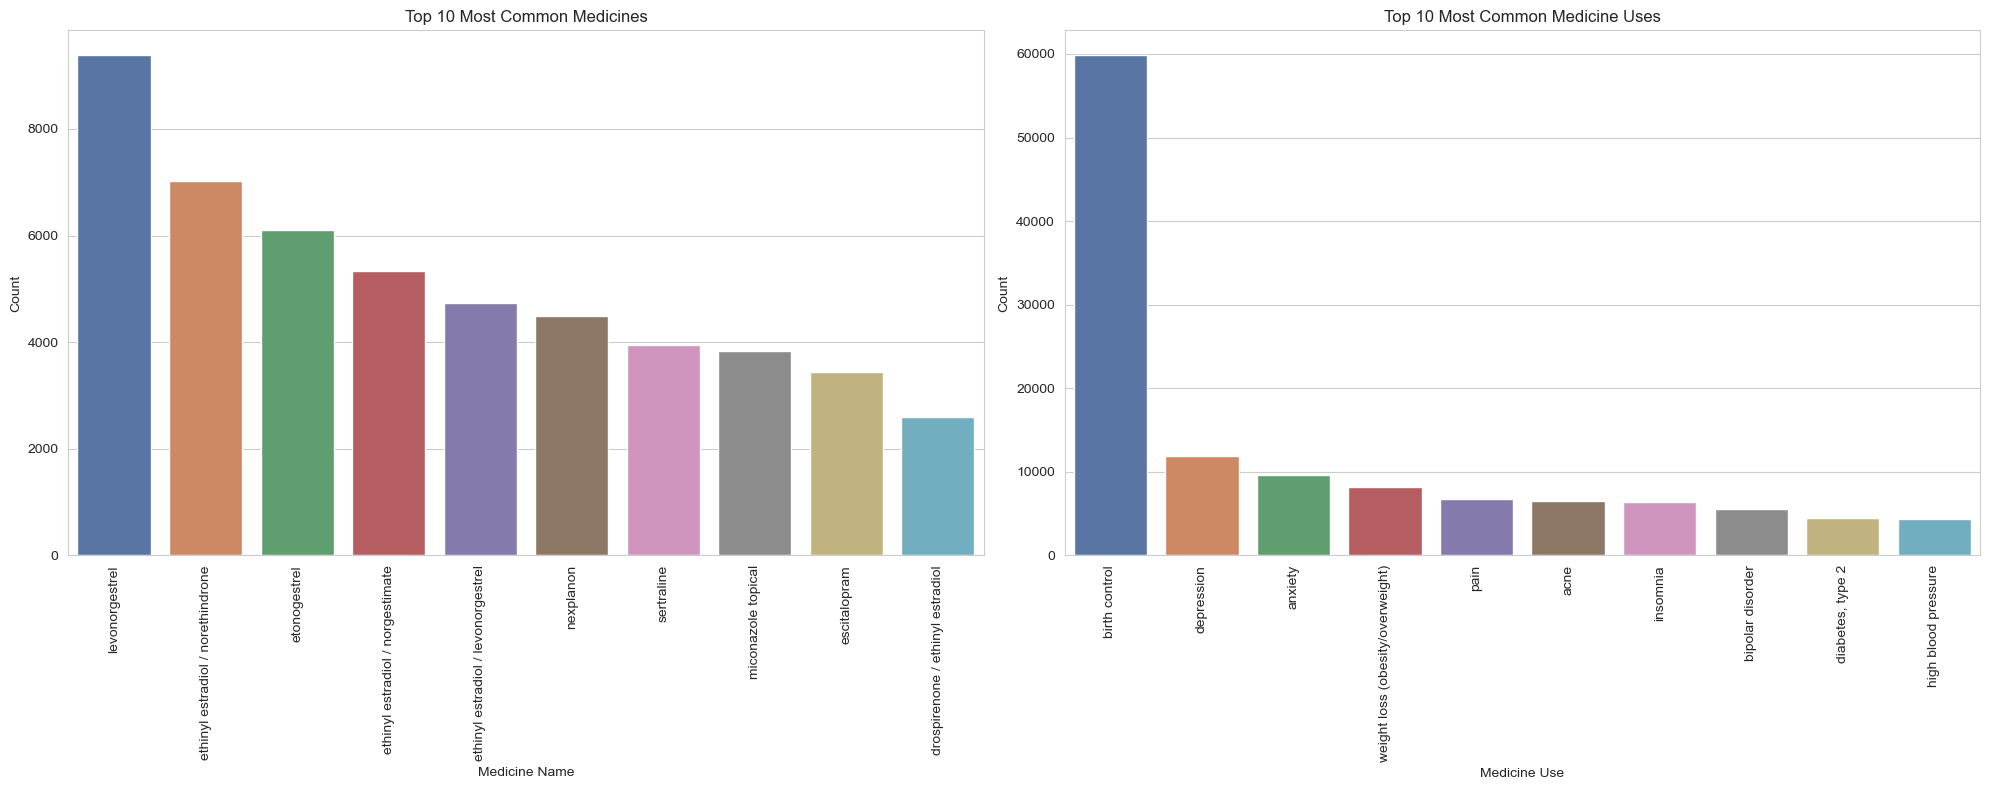

In [257]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Top 10 most common medicines
sns.barplot(
    x=top10_medicines.index,
    y=top10_medicines.values,
    palette='deep',
    ax=axes[0]
)
axes[0].set_title('Top 10 Most Common Medicines')
axes[0].set_xlabel('Medicine Name')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)

# Top 10 most common medicine uses
sns.barplot(
    x=top10_conditions.index,
    y=top10_conditions.values,
    palette='deep',
    ax=axes[1]
)
axes[1].set_title('Top 10 Most Common Medicine Uses')
axes[1].set_xlabel('Medicine Use')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('top10_med_cond.png')
plt.show()

In [174]:
top_medicines_per_condition['MedicineFor'] = pd.Categorical(
    top_medicines_per_condition['MedicineFor'],
    categories=top5_conditions,
    ordered=True
)

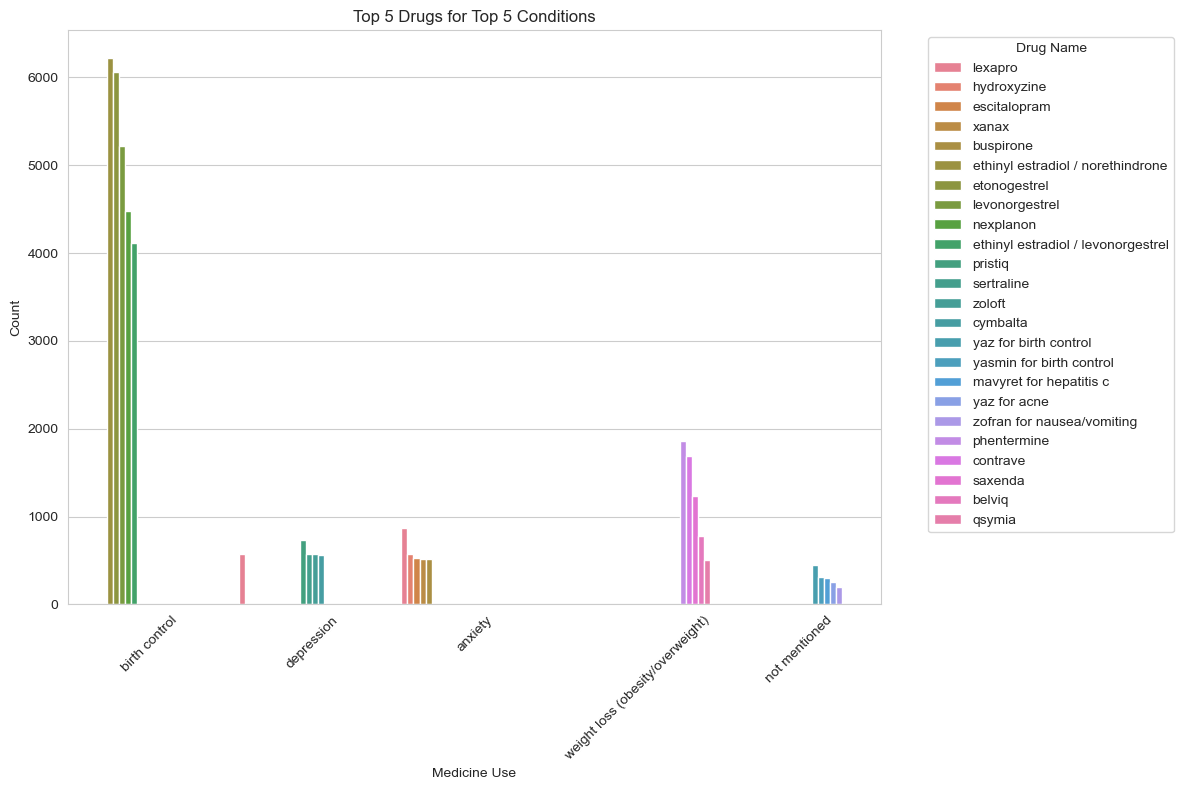

In [175]:
sns.set_style("whitegrid")
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_medicines_per_condition,
    x='MedicineFor',
    y='count',
    hue='MedicineName',
    width=0.9,
    dodge=True
)

plt.title('Top 5 Drugs for Top 5 Conditions')
plt.xlabel('Medicine Use')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Drug Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

NameError: name 'style_ax' is not defined

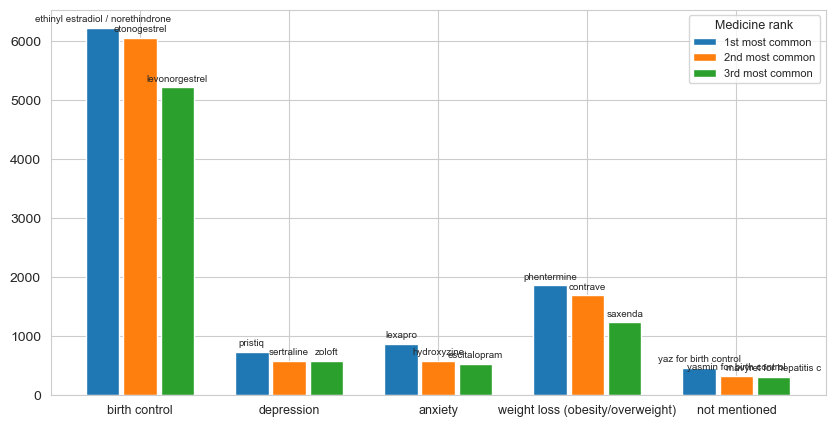

In [188]:
# ── TOP 3 MEDICINES PER TOP 5 CONDITIONS ─────────────────────────────────────
top5_cond = df['MedicineFor'].value_counts().head(5).index.tolist()
cross = (df[df['MedicineFor'].isin(top5_cond)]
        .groupby(['MedicineFor', 'MedicineName']).size()
        .reset_index(name='count')
        .sort_values(['MedicineFor', 'count'], ascending=[True, False]))
top3 = cross.groupby('MedicineFor').head(3)

# Assign a rank (1st, 2nd, 3rd most common drug) per condition
top3 = top3.copy()
top3['rank'] = top3.groupby('MedicineFor').cumcount()  # 0, 1, 2

fig, ax = plt.subplots(figsize=(10, 5))

width      = 0.25                          # width of each bar
x_pos      = np.arange(len(top5_cond))    # one position per condition
x_map      = {c: i for i, c in enumerate(top5_cond)}
rank_labels = ['1st most common', '2nd most common', '3rd most common']

for rank in range(3):
    sub       = top3[top3['rank'] == rank]
    positions = [x_map[c] + (rank - 1) * width for c in sub['MedicineFor']]
    bars      = ax.bar(positions, sub['count'].values,
                       width=width * 0.9,
                       label=rank_labels[rank])
    # Value labels on top of each bar
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ax.get_ylim()[1] * 0.01,
                row['MedicineName'],          # drug name as label
                ha='center', va='bottom',
                fontsize=7,
                rotation=0)

ax.set_xticks(x_pos)
ax.set_xticklabels(top5_cond, fontsize=9)
ax.legend(title='Medicine rank', fontsize=8, title_fontsize=9,
          loc='upper right', framealpha=0.8)
style_ax(ax, 'Top 3 Medicines per Top 5 Conditions',
         'MedicineFor', 'Number of Reviews', grid_axis='y')

plt.tight_layout(pad=1.5)
plt.savefig('g1c_top3_per_cond.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_6930/1050923119.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


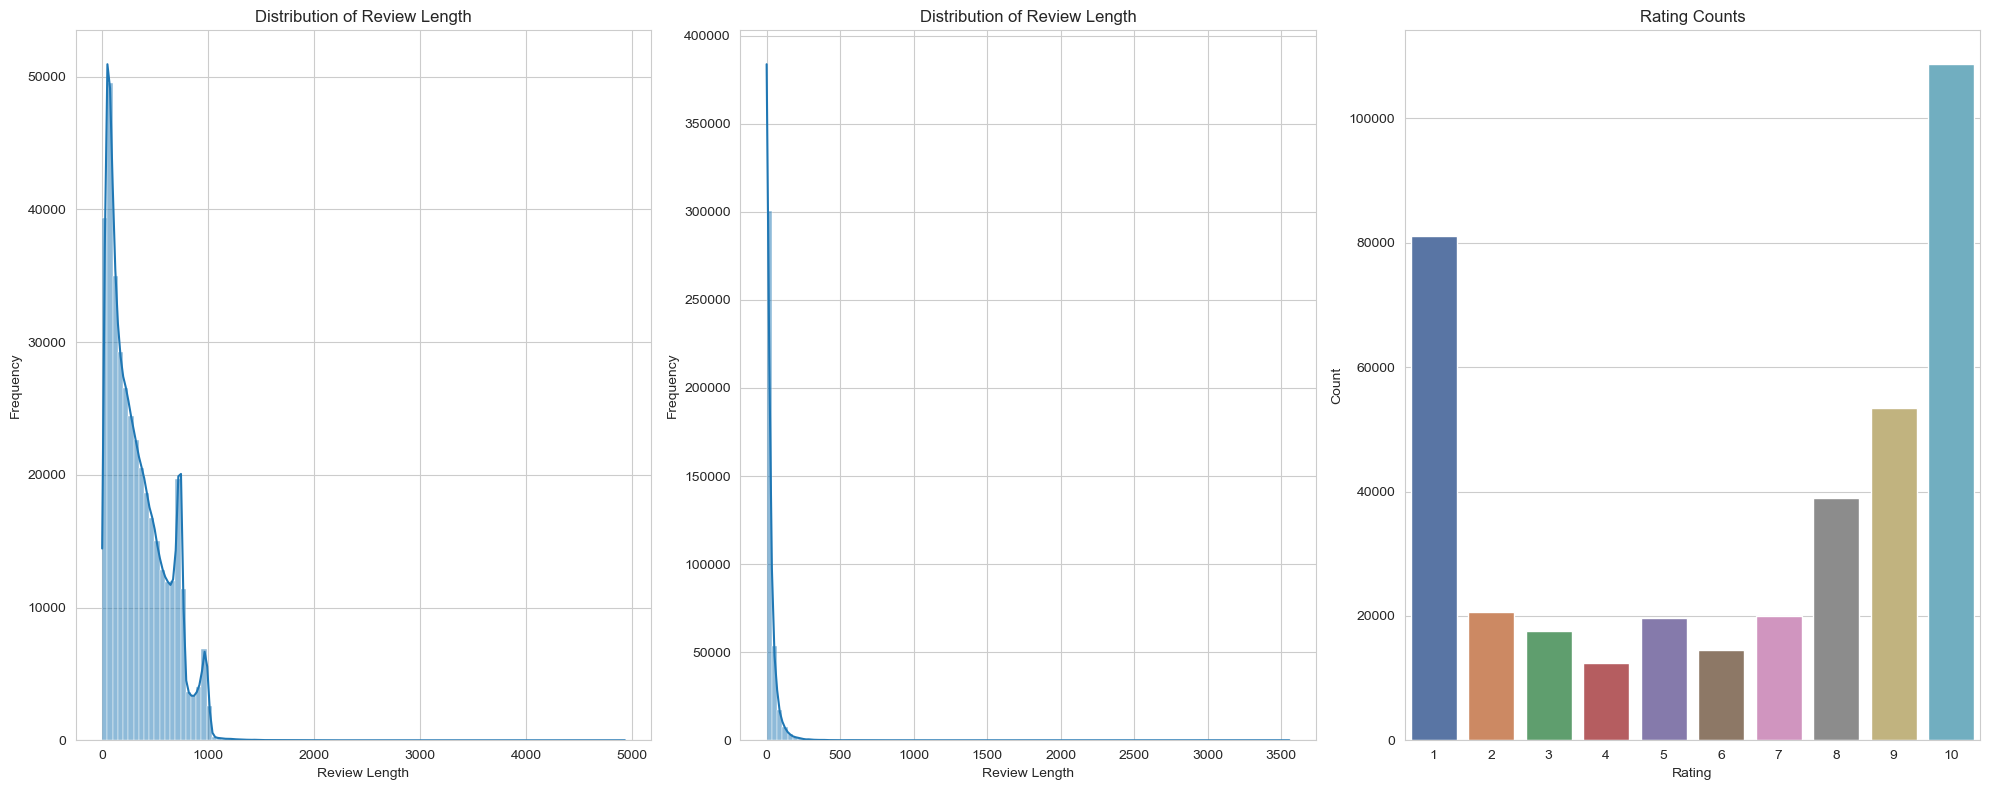

In [259]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Distribution of review lenght
sns.histplot(
    df['ReviewLength'],
    bins=100,
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Distribution of Review Length')
axes[0].set_xlabel('Review Length')
axes[0].set_ylabel('Frequency')

# Distribution of number of likes
sns.histplot(
    df['NumberOfLikes'],
    bins=100,
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Distribution of Review Length')
axes[1].set_xlabel('Review Length')
axes[1].set_ylabel('Frequency')

# Rating Counts
rating_counts = df['Rating'].value_counts().sort_index()
sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    palette='deep',
    ax=axes[2]
)
axes[2].set_title('Rating Counts')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Count')

# Show graph
plt.tight_layout()
plt.show()

/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_6930/3291022433.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_6930/3291022433.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_6930/3291022433.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


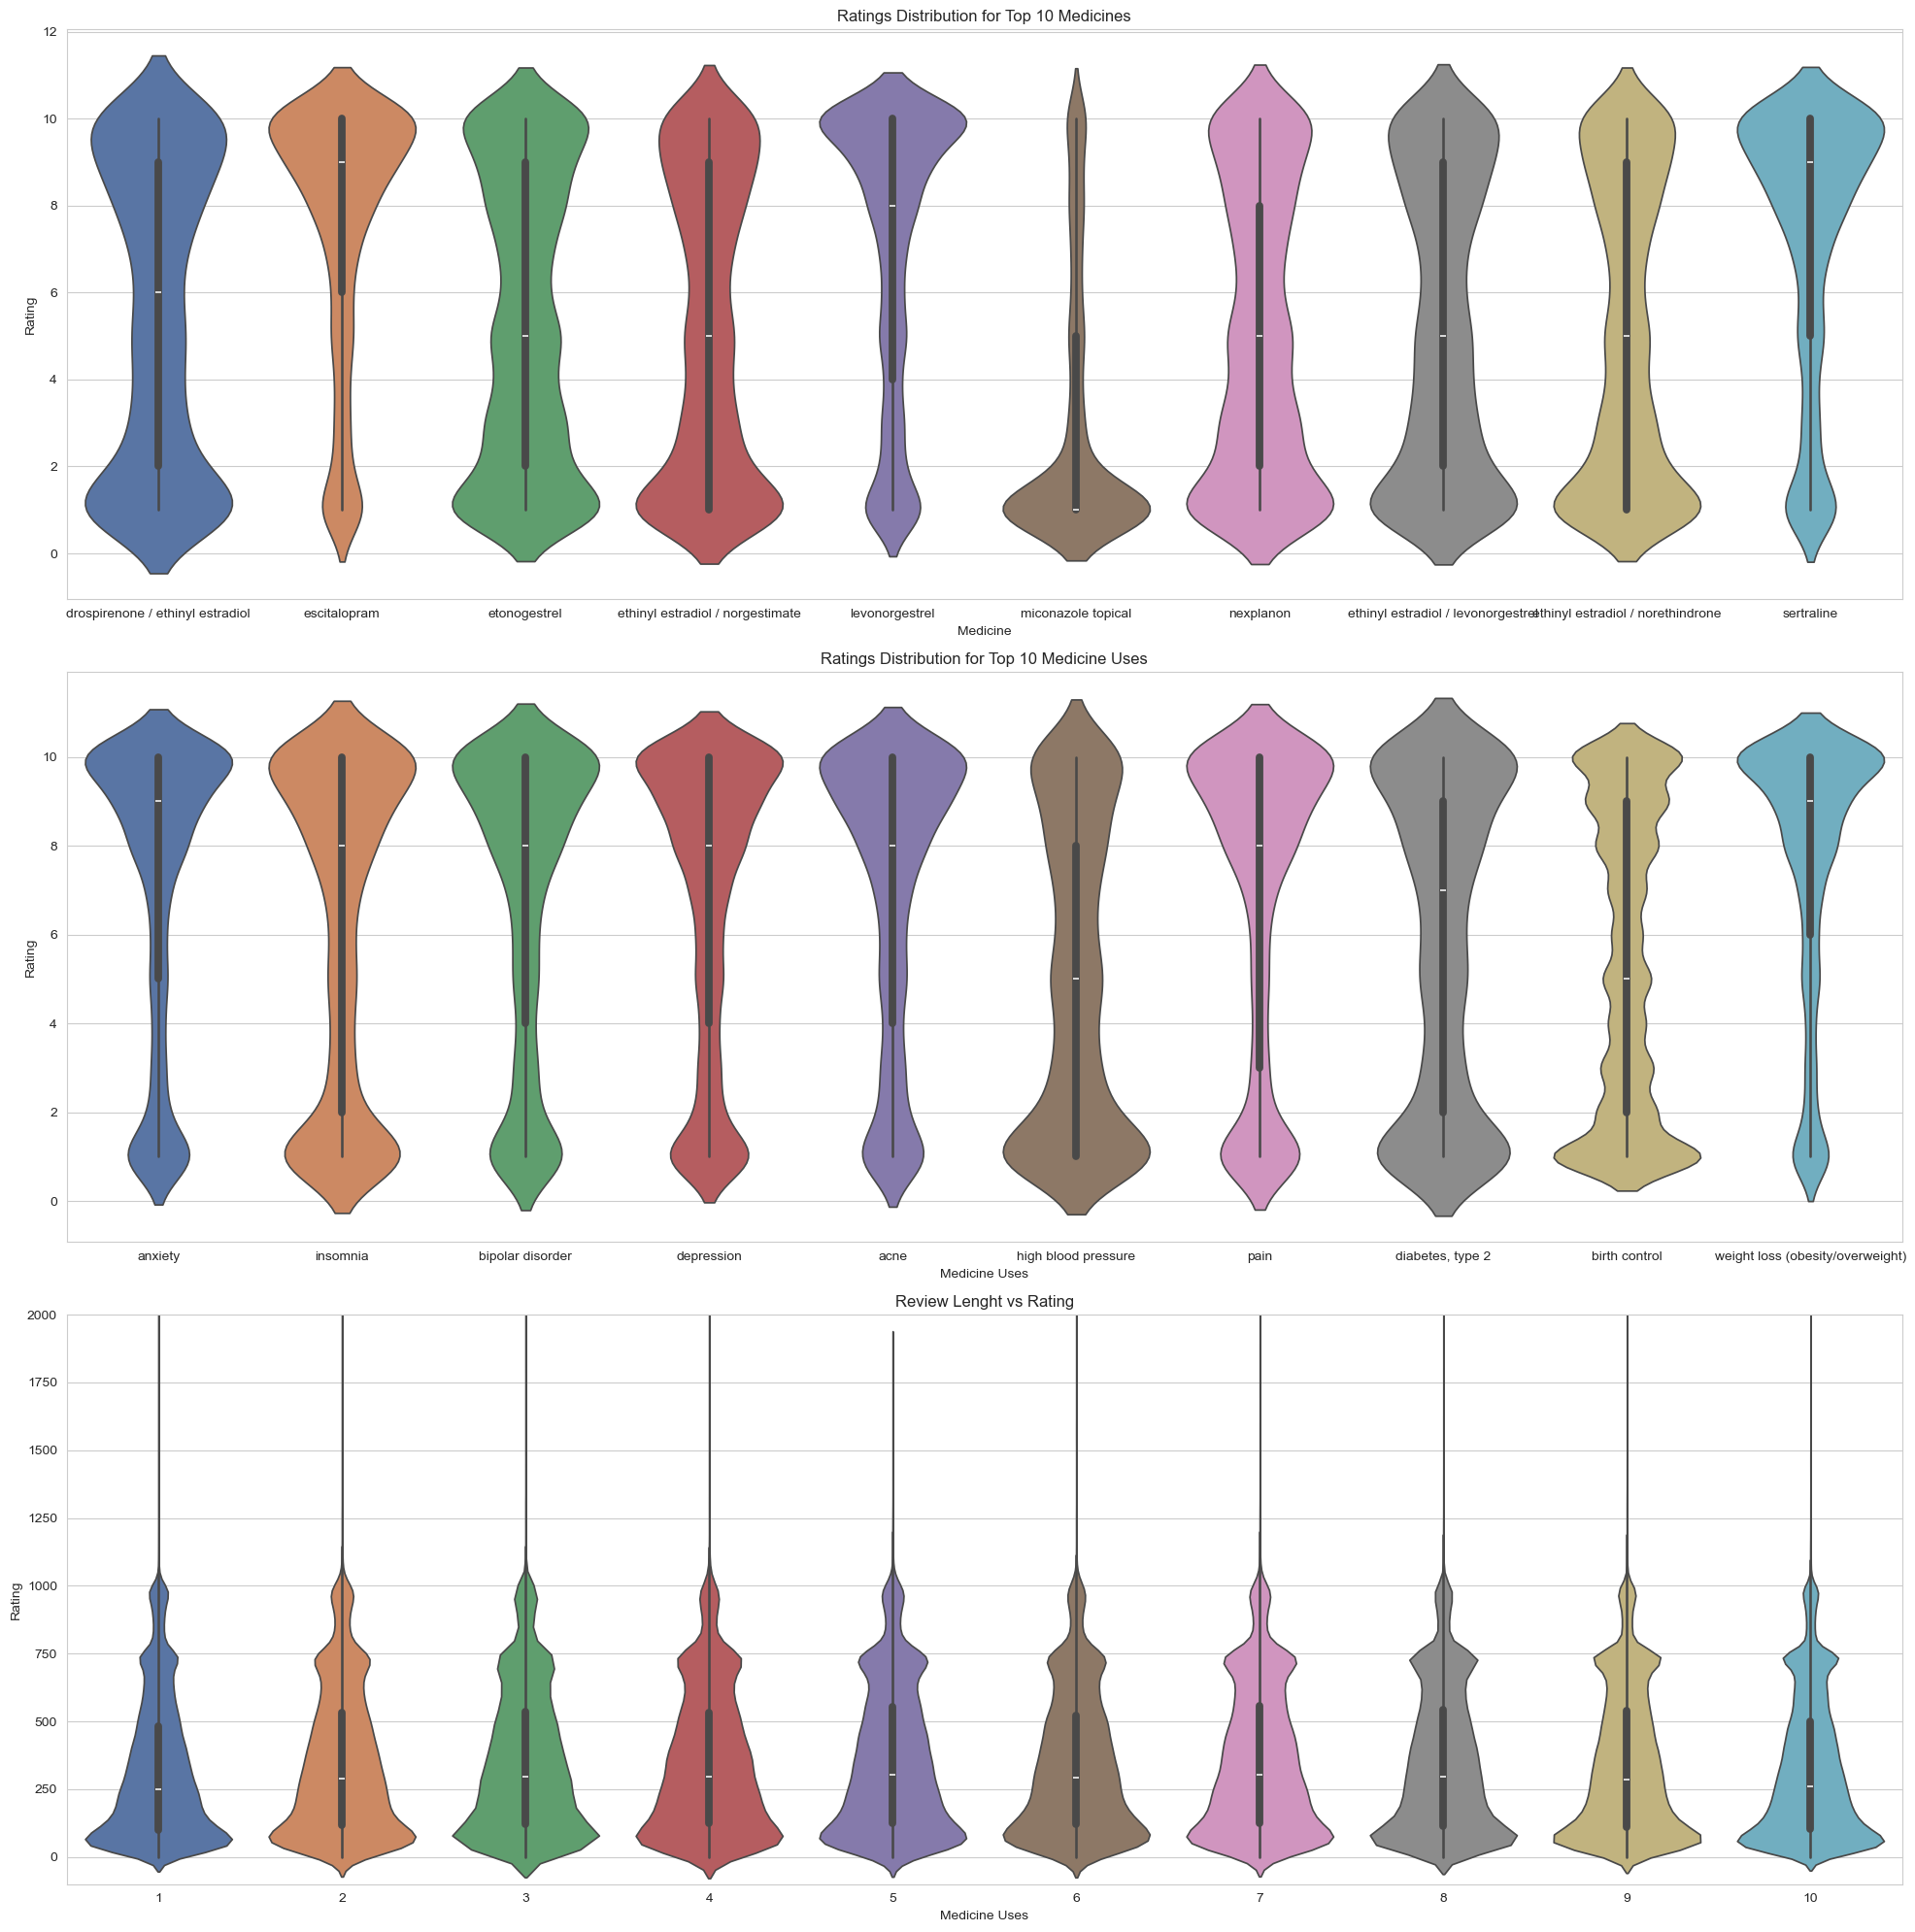

In [261]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(20, 20))

# Top 10 medicines vs ratings
sns.violinplot(
    x="MedicineName",
    y="Rating",
    data=df[df['MedicineName'].isin(top10_medicines.index)],
    palette='deep',
    ax=axes[0]
)
axes[0].set_title('Ratings Distribution for Top 10 Medicines')
axes[0].set_xlabel('Medicine')
axes[0].set_ylabel('Rating')


# Top 10 medicine uses vs ratings
sns.violinplot(
    x="MedicineFor",
    y="Rating",
    data=df[df['MedicineFor'].isin(top10_conditions.index)],
    palette='deep',
    ax=axes[1]
)
axes[1].set_title('Ratings Distribution for Top 10 Medicine Uses')
axes[1].set_xlabel('Medicine Uses')
axes[1].set_ylabel('Rating')

# Review lenght vs rating
sns.violinplot(
    x="Rating",
    y="ReviewLength",
    data=df,
    palette='deep',
    ax=axes[2]
)
axes[2].set_title('Review Lenght vs Rating')
axes[2].set_xlabel('Medicine Uses')
axes[2].set_ylabel('Rating')
axes[2].set_ylim(-100,2000)


# Show graph
plt.tight_layout()
plt.show()